Generating a 30-second signal for stage 'REM'...


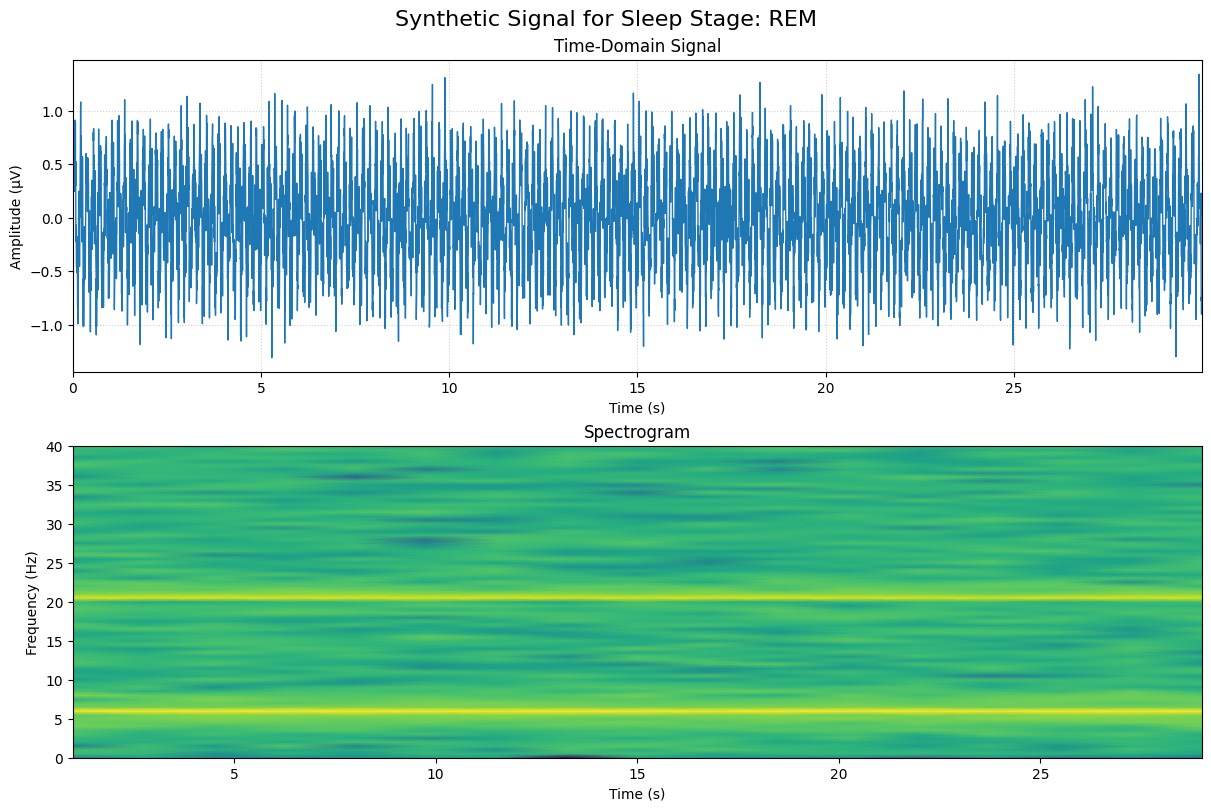

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def generate_sleep_signal(stage, duration=30, fs=256):
    """
    Generates a synthetic EEG signal characteristic of a specific sleep stage.

    Args:
        stage (str): The sleep stage to generate ('W', 'N1', 'N2', 'N3', 'REM').
        duration (int): The duration of the signal in seconds.
        fs (int): The sampling frequency in Hz.

    Returns:
        tuple: A tuple containing the time vector and the generated signal.
    """
    t = np.linspace(0, duration, duration * fs, endpoint=False)
    sig = np.zeros_like(t)

    # Define characteristic frequencies based on the AASM manual and the report
    delta = (0.5, 4)
    theta = (4, 8)
    alpha = (8, 12)
    sigma = (12, 16) # For sleep spindles in N2
    beta = (16, 30)

    # Generate signal components based on the selected stage
    if stage == 'W':
        # Wake is characterized by alpha and beta waves
        sig += 0.5 * np.sin(2 * np.pi * np.random.uniform(alpha[0], alpha[1]) * t)
        sig += 0.3 * np.sin(2 * np.pi * np.random.uniform(beta[0], beta[1]) * t)
    elif stage == 'N1':
        # N1 is a transition with decreasing alpha and increasing theta
        sig += 0.2 * np.sin(2 * np.pi * np.random.uniform(alpha[0], alpha[1]) * t)
        sig += 0.8 * np.sin(2 * np.pi * np.random.uniform(theta[0], theta[1]) * t)
    elif stage == 'N2':
        # N2 has a theta background with sleep spindles (sigma waves)
        sig += 0.7 * np.sin(2 * np.pi * np.random.uniform(theta[0], theta[1]) * t)
        # Add a 1-second sleep spindle burst
        spindle_start = int(fs * 10)
        spindle_end = int(fs * 11.5)
        spindle_t = t[spindle_start:spindle_end]
        spindle_freq = np.random.uniform(sigma[0], sigma[1])
        spindle_wave = 1.2 * np.sin(2 * np.pi * spindle_freq * spindle_t)
        # Apply a window to make the spindle burst look natural
        spindle_wave *= signal.windows.tukey(len(spindle_wave), alpha=0.5)
        sig[spindle_start:spindle_end] += spindle_wave
    elif stage == 'N3':
        # N3 is dominated by high-amplitude, slow delta waves
        sig += 1.5 * np.sin(2 * np.pi * np.random.uniform(delta[0], delta[1]) * t)
        sig += 0.3 * np.sin(2 * np.pi * np.random.uniform(theta[0], theta[1]) * t)
    elif stage == 'REM':
        # REM has low-amplitude, mixed-frequency waves, similar to N1
        sig += 0.5 * np.sin(2 * np.pi * np.random.uniform(theta[0], theta[1]) * t)
        sig += 0.3 * np.sin(2 * np.pi * np.random.uniform(beta[0], beta[1]) * t)

    # Add some random noise to make the signal more realistic
    sig += 0.2 * np.random.randn(len(t))

    return t, sig

def plot_signal_and_spectrogram(t, sig, stage, fs):
    """
    Plots the generated signal and its spectrogram.

    Args:
        t (np.ndarray): The time vector.
        sig (np.ndarray): The signal vector.
        stage (str): The name of the sleep stage.
        fs (int): The sampling frequency.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
    fig.suptitle(f'Synthetic Signal for Sleep Stage: {stage}', fontsize=16)

    # Plot the time-domain signal
    ax1.plot(t, sig, lw=1)
    ax1.set_title('Time-Domain Signal')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude (µV)')
    ax1.set_xlim(0, t[-1])
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Plot the spectrogram
    f, times, Sxx = signal.spectrogram(sig, fs, nperseg=fs*2) # Use 2-second windows
    # Limit frequency display to a reasonable range for EEG
    freq_limit_idx = np.where(f <= 40)[0]
    ax2.pcolormesh(times, f[freq_limit_idx], 10 * np.log10(Sxx[freq_limit_idx, :]), shading='gouraud', cmap='viridis')
    ax2.set_title('Spectrogram')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Frequency (Hz)')

    plt.show()

if __name__ == '__main__':
    # --- USER CONTROL ---
    # Change this variable to generate a signal for a different sleep stage.
    # Options: 'W', 'N1', 'N2', 'N3', 'REM'
    stage_to_generate = 'REM'
    # ------------------

    SAMPLING_RATE = 256 # Hz
    DURATION = 30 # seconds (to match one epoch)

    print(f"Generating a {DURATION}-second signal for stage '{stage_to_generate}'...")

    time_vector, generated_signal = generate_sleep_signal(
        stage=stage_to_generate,
        duration=DURATION,
        fs=SAMPLING_RATE
    )

    plot_signal_and_spectrogram(
        t=time_vector,
        sig=generated_signal,
        stage='REM',
        fs=SAMPLING_RATE
    )
